In [1]:
%load_ext autoreload
%autoreload 2
!hostname
!pwd
import os, sys
print(sys.executable)

slurm0-gpu1nodeset-0
/home/akarsh_sakana_ai/alife-repr
/home/akarsh_sakana_ai/.conda/envs/asal/bin/python


In [2]:
import os, sys, glob, pickle
from functools import partial

import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_theme()

from tqdm.auto import tqdm
from einops import rearrange, reduce, repeat

In [3]:
# import experiment_utils
import time
import subprocess

# Launch Experiment (on this node)

In [4]:
exp_sh = f'./src/science_scripts/train_dt.sh'
with open(exp_sh, 'r') as f:
    commands = [c for c in f.read().split('\n') if c]
# commands = ['python temp.py' for _ in range(8)]

commands_str = ""
for c in commands:
    c = c.replace('"', '\\"') # change all inner double quotes to escaped double quotes
    commands_str += '    "'+c+'"\n'

print(len(commands))

144


In [5]:
home_dir = os.path.expanduser("~")
job_name = exp_sh.split('/')[-1]
# job_name = "alife-repr"
log_dir = f'{home_dir}/logs/{time.strftime("%Y_%m_%d_%H_%M_%S")}'

slurm_str = f"""#!/bin/bash
#SBATCH --job-name="{job_name}"
#SBATCH --partition=a3

#SBATCH --output={log_dir}/%a.out
#SBATCH --error={log_dir}/%a.err
#SBATCH --array=0-{len(commands)-1}%8

#SBATCH --cpus-per-task=26
#SBATCH --time="24:00:00"
#SBATCH --nodes=1
#SBATCH --gres=gpu:1
#SBATCH --mem=128G

#SBATCH --export=""
#SBATCH --chdir="/home/akarsh_sakana_ai/alife-repr/src"


commands=(
{commands_str}
)

source /home/akarsh_sakana_ai/miniconda3/etc/profile.d/conda.sh
conda activate asal

eval "stdbuf -oL ${{commands[$SLURM_ARRAY_TASK_ID]}}"
# eval is needed for proper handling of quotes, stdbuf is needed for proper buffering
"""

print(slurm_str)

#!/bin/bash
#SBATCH --job-name="train_dt.sh"
#SBATCH --partition=a3

#SBATCH --output=/home/akarsh_sakana_ai/logs/2025_07_06_19_30_55/%a.out
#SBATCH --error=/home/akarsh_sakana_ai/logs/2025_07_06_19_30_55/%a.err
#SBATCH --array=0-143%8

#SBATCH --cpus-per-task=26
#SBATCH --time="24:00:00"
#SBATCH --nodes=1
#SBATCH --gres=gpu:1
#SBATCH --mem=128G

#SBATCH --export=""
#SBATCH --chdir="/home/akarsh_sakana_ai/alife-repr/src"


commands=(
    "python train_dt.py --seed=0 --save_dir=\"/home/akarsh_sakana_ai/alife-repr-data/run_3/seed=0_gol=6152_dt=1_block=conv\"   --n_iters=50000 --log_every=10000 --model.layers=8 --model.n_embd=64 --model.n_head=8 --model.block=\"conv\" --model.nt=1 --model.nh=32 --model.nw=32 --model.pt=1 --model.ph=2 --model.pw=2 --opt.batch_size=32 --opt.learning_rate=0.0003 --opt.weight_decay=1e-05 --opt.clip_grad_norm=1.0 --data.gol_params=6152 --data.grid_size=64 --data.t_start=32 --data.t_end=64 --data.dt=1  "
    "python train_dt.py --seed=0 --save_dir=\"/home/akars

In [6]:
!mkdir -p {log_dir}
!rm {os.path.dirname(log_dir)+'/latest'}
!ln -sf {log_dir} {os.path.dirname(log_dir)+'/latest'}

with open(f'{log_dir}/slurm.sh', 'w') as f:
    f.write(slurm_str)

In [7]:
popen = subprocess.Popen(f'sbatch {log_dir}/slurm.sh', shell=True)

Submitted batch job 70634


In [9]:
print(log_dir) # for main

/home/akarsh_sakana_ai/logs/2025_07_06_19_30_55


In [30]:
header = '\n'.join([
    '#!/bin/bash',
    
    # 'source ~/.virtualenvs/nca-alife-torch/bin/activate'
    
    'source ~/miniconda3/etc/profile.d/conda.sh',
    'conda activate nca-alife-jax',
    
    'cd ~/nca-alife/src'
])


gpus = [2, 3, 4, 5, 6, 7]
log_dir = os.path.expanduser(f'~/nca-alife-data/logs/{time.strftime("%Y_%m_%d_%H_%M_%S")}')
exp_sh = f'./src/experiments/main.sh'
with open(exp_sh, 'r') as f:
    commands = [c for c in f.read().split('\n') if c]
print(f"{exp_sh} has {len(commands)} commands: ")
print('\n'.join(commands[:3]), '\n...')
print(f"Logging to {log_dir}")

./src/experiments/main.sh has 6 commands: 
python main_illuminate_lenia.py  --k_nbrs=2 --n_iters=10000 --save_dir="/home/akarshkumar0101/nca-alife-data/illumination/lenia"
python main_illuminate_plenia.py --k_nbrs=2 --n_iters=120000  --save_dir="/home/akarshkumar0101/nca-alife-data/illumination/plenia"
python main_illuminate_nca.py    --k_nbrs=2 --n_iters=12000  --save_dir="/home/akarshkumar0101/nca-alife-data/illumination/nca" 
...
Logging to /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03


In [31]:
print(log_dir)

/home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03


In [32]:
!mkdir -p {log_dir}
!rm {os.path.dirname(log_dir)+'/latest'}
!ln -sf {log_dir} {os.path.dirname(log_dir)+'/latest'}
for i_gpu, gpu in enumerate(gpus):
    job_ids = np.arange(len(commands))[i_gpu::len(gpus)]
    cvd = f'export CUDA_VISIBLE_DEVICES={gpu}'
    txt = f"{header}\n{cvd}\n\n"
    for job_id in job_ids:
        txt += f"touch {log_dir}/job_{job_id:05d}.status\n"
        txt += f"{commands[job_id]} &> {log_dir}/job_{job_id:05d}.out\n"
        txt += f"echo $? > {log_dir}/job_{job_id:05d}.status\n\n"
    with open(f"{log_dir}/gpu_{gpu}.sh", "w") as f:
        f.write(txt)

In [33]:
print('\n'.join(txt.split('\n')[:24]))

#!/bin/bash
source ~/miniconda3/etc/profile.d/conda.sh
conda activate nca-alife-jax
cd ~/nca-alife/src
export CUDA_VISIBLE_DEVICES=7

touch /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/job_00005.status
python main_illuminate_plife.py  --k_nbrs=2 --n_iters=800    --save_dir="/home/akarshkumar0101/nca-alife-data/illumination/plife" &> /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/job_00005.out
echo $? > /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/job_00005.status




In [34]:
for i_gpu, gpu in enumerate(gpus):
    command = f"bash {log_dir}/gpu_{gpu}.sh"
    print(command)
    process = subprocess.Popen(command, shell=True)

bash /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/gpu_2.sh
bash /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/gpu_3.sh
bash /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/gpu_4.sh
bash /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/gpu_5.sh
bash /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/gpu_6.sh
bash /home/akarshkumar0101/nca-alife-data/logs/2024_08_27_02_37_03/gpu_7.sh


# Track Experiment

In [13]:
import subprocess
a = subprocess.run(['ps', 'ux'], stdout=subprocess.PIPE).stdout.decode('utf-8')

In [14]:
[l for l in a.split('\n') if "bash" in l and "gpu" in l]

[]

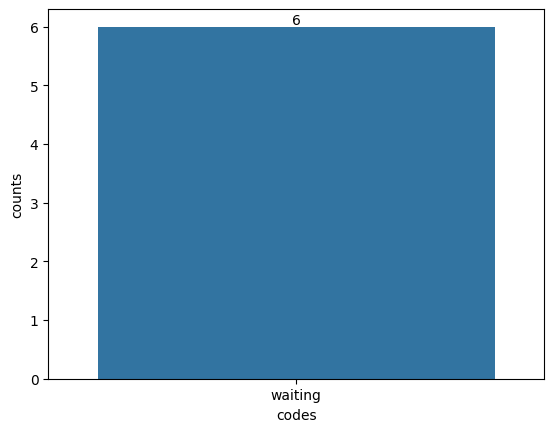

In [15]:
from collections import defaultdict

status = []
for job_id in range(len(commands)):
    try:
        with open(f"{log_dir}/job_{job_id:05d}.status", "r") as f:
            status.append(int(f.read().strip()))
    except Exception as e:
        status.append("waiting")
status = np.array(status)

codes, counts = np.unique(status, return_counts=True)
df = pd.DataFrame(dict(codes=codes, counts=counts))
ax = sns.barplot(data=df, x='codes', y='counts')
ax.bar_label(ax.containers[0], fontsize=10);

In [16]:
for job_id in list(range(len(commands))):
    print()
    print(f'------------------------------------------------------ {job_id} ------------------------------------------------------')
    print()
    try:
        with open(f"{log_dir}/job_{job_id:05d}.out", "r") as f:
            print(f.readlines()[-1].strip())
    except Exception as e:
        # pass
        break
        print(e)


------------------------------------------------------ 0 ------------------------------------------------------



In [17]:
log_dir

'/home/akarsh_sakana_ai/logs/2025_04_07_05_35_49'